Лаброаторная работа №3.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Генерация случайного датасета.

In [12]:
np.random.seed(42)
n_samples = 800
X1 = np.random.uniform(0, 10, n_samples)
X2 = np.random.uniform(5, 15, n_samples)
X3 = np.random.normal(8, 3, n_samples)
true_coef = [4.2, -1.8, 2.5]
y = (true_coef[0] * X1 +
     true_coef[1] * X2 +
     true_coef[2] * X3 +
     np.random.normal(0, 3.5, n_samples))
df = pd.DataFrame({
    'feature1': X1,
    'feature2': X2,
    'feature3': X3,
    'target': y
})

print("Первые 5 строк датасета:")
display(df.head())

Первые 5 строк датасета:


,feature1,feature2,feature3,target
0,3.745401,12.072386,6.254957,7.803473
1,9.507143,6.525390,4.955730,41.106865
2,7.319939,10.762884,6.052167,23.622504
3,5.986585,11.067150,4.328179,19.966841
4,1.560186,9.241307,8.102250,10.174782


Анализ данных.


Основная статистика:


,feature1,feature2,feature3,target
count,800.00,800.00,800.00,800.00
mean,4.97,10.00,8.11,23.25
std,2.94,2.93,2.98,15.73
min,0.05,5.05,-1.06,-23.12
25%,2.41,7.35,6.13,12.50
50%,5.07,10.05,8.06,23.39
75%,7.54,12.40,10.09,34.56
max,10.00,14.99,17.58,70.78



Корреляции с целевой переменной:
target      1.000
feature1    0.787
feature3    0.484
feature2   -0.341
Name: target, dtype: float64


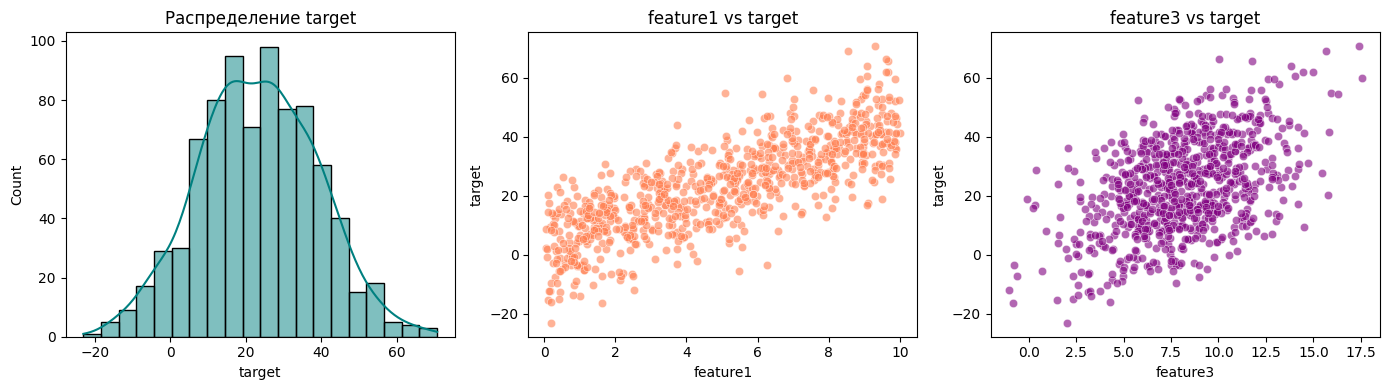

In [13]:
print("\nОсновная статистика:")
display(df.describe().round(2))
print("\nКорреляции с целевой переменной:")
print(df.corr()['target'].sort_values(ascending=False).round(3))
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
sns.histplot(df['target'], kde=True, color='teal')
plt.title('Распределение target')
plt.subplot(1, 3, 2)
sns.scatterplot(x='feature1', y='target', data=df, alpha=0.6, color='coral')
plt.title('feature1 vs target')
plt.subplot(1, 3, 3)
sns.scatterplot(x='feature3', y='target', data=df, alpha=0.6, color='purple')
plt.title('feature3 vs target')
plt.tight_layout()
plt.show()

Подготовка данных.


In [14]:
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки : {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Размер обучающей выборки: (640, 3)
Размер тестовой выборки : (160, 3)


Обучение и сравнение моделей.

In [15]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
}

results = []

for name, model in models.items():
    if "Linear" in name or "Ridge" in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': round(mae, 3),
        'RMSE': round(rmse, 3),
        'R²': round(r2, 4)
    })
    print(f"\n{name}")
    print(f"  MAE  = {mae:.3f}")
    print(f"  RMSE = {rmse:.3f}")
    print(f"  R²   = {r2:.4f}")

results_df = pd.DataFrame(results)
print("\nСравнение моделей:")
display(results_df)


Linear Regression
  MAE  = 2.756
  RMSE = 3.452
  R²   = 0.9543

Ridge Regression
  MAE  = 2.760
  RMSE = 3.455
  R²   = 0.9542

Random Forest
  MAE  = 3.309
  RMSE = 4.197
  R²   = 0.9325

Сравнение моделей:


,Model,MAE,RMSE,R²
0,Linear Regression,2.756,3.452,0.9543
1,Ridge Regression,2.760,3.455,0.9542
2,Random Forest,3.309,4.197,0.9325


Визуализация лучшей модели.


Лучшая модель по R²: Linear Regression


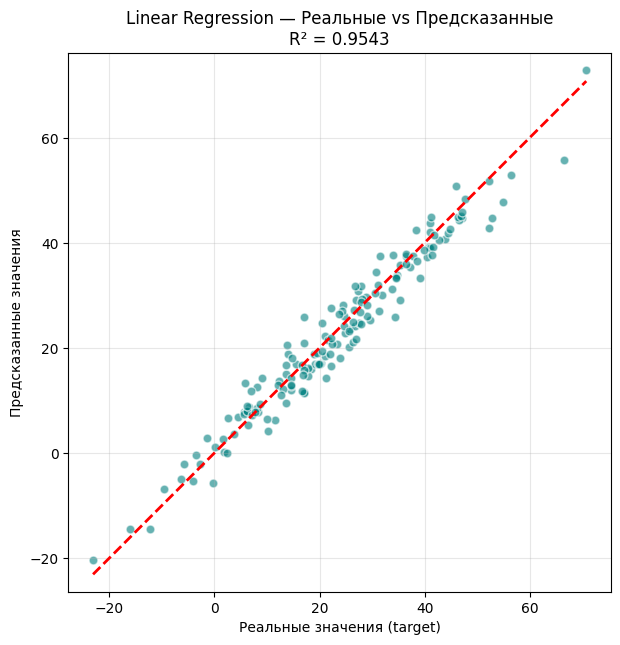

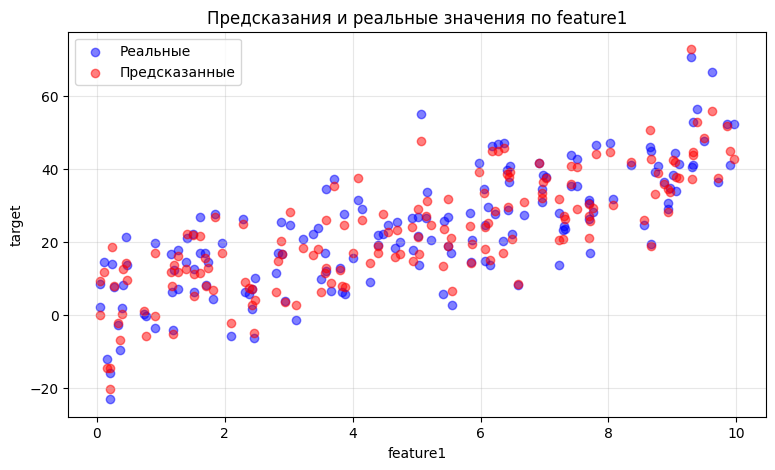

In [16]:
best_model_name = results_df.loc[results_df['R²'].idxmax(), 'Model']
print(f"\nЛучшая модель по R²: {best_model_name}")
if "Forest" in best_model_name:
    best_model = models['Random Forest']
    y_pred_best = best_model.predict(X_test)
else:
    best_model = models[best_model_name]
    y_pred_best = best_model.predict(X_test_scaled)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.6, color='teal', edgecolor='white', s=40)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальные значения (target)')
plt.ylabel('Предсказанные значения')
plt.title(f'{best_model_name} — Реальные vs Предсказанные\nR² = {r2_score(y_test, y_pred_best):.4f}')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()
plt.figure(figsize=(9, 5))
plt.scatter(X_test['feature1'], y_test, color='blue', alpha=0.5, label='Реальные')
plt.scatter(X_test['feature1'], y_pred_best, color='red', alpha=0.5, label='Предсказанные')
plt.xlabel('feature1')
plt.ylabel('target')
plt.title('Предсказания и реальные значения по feature1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()